In [3]:
# import torch
# print("Supported Archs:", torch.cuda.get_arch_list()) # Should now contain 'sm_60'

# import os
# os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

import torch, gc

# 1. تأكد الـ GPU فاضية
gc.collect()
torch.cuda.empty_cache()

# 2. شوف كام free قبل ما تحمّل أي حاجة
free, total = torch.cuda.mem_get_info()
print(f"Free: {free/1e9:.2f} GB / Total: {total/1e9:.2f} GB")

# 3. بعدين حمّل الـ data والـ model

Free: 15.53 GB / Total: 15.64 GB


In [4]:
import torch

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [6]:
from PIL import Image
import matplotlib.pyplot as plt

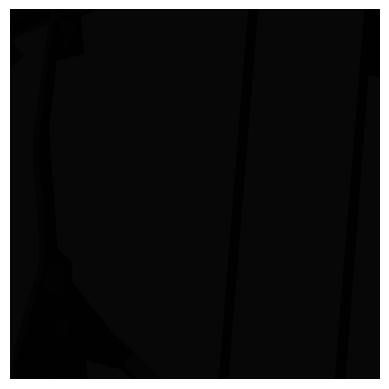

In [7]:
mask = Image.open("/kaggle/input/datasets/mohammedjaveed/loveda-dataset/Train/Train/Rural/masks_png/0.png").convert("RGB")
plt.imshow(mask)
plt.axis("off")
plt.show()

In [8]:
import numpy as np

mask = Image.open(
    "/kaggle/input/datasets/mohammedjaveed/loveda-dataset/Train/Train/Rural/masks_png/0.png"
)

mask_array = np.array(mask)

print(mask_array.shape)
print(np.unique(mask_array))

(1024, 1024)
[1 2 3 4 7]


In [9]:
print(mask_array)

[[2 2 2 ... 1 1 1]
 [2 2 2 ... 1 1 1]
 [2 2 2 ... 1 1 1]
 ...
 [3 3 3 ... 7 7 7]
 [3 3 3 ... 7 7 7]
 [3 3 3 ... 7 7 7]]


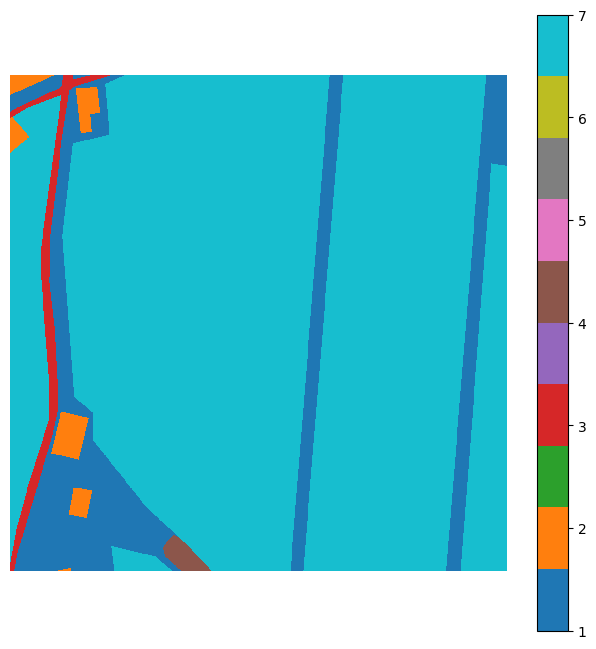

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))

plt.imshow(mask_array, cmap="tab10", interpolation="nearest")

plt.colorbar()
plt.axis("off")
plt.show()

In [11]:
import numpy as np
from PIL import Image

mask = Image.open(
    "/kaggle/input/datasets/mohammedjaveed/loveda-dataset/Train/Train/Rural/masks_png/0.png"
)

mask_array = np.array(mask)

print(np.unique(mask_array))

classes = {
    0: "No-data / Ignore",
    1: "Background",
    2: "Building",
    3: "Road",
    4: "Water",
    5: "Barren",
    6: "Forest",
    7: "Agriculture"
}

for class_id in np.unique(mask_array):
    count = np.sum(mask_array == class_id)
    print(f"{class_id}: {classes[class_id]} -> {count} pixels")

[1 2 3 4 7]
1: Background -> 142441 pixels
2: Building -> 14427 pixels
3: Road -> 19208 pixels
4: Water -> 3888 pixels
7: Agriculture -> 868612 pixels


In [12]:
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms as T
from pathlib import Path
from PIL import Image
from matplotlib import pyplot as plt


In [13]:
IMG_SIZE=512

image_transforms = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    # T.Normalize(
    #     mean=[0.485, 0.456, 0.406],
    #     std=[0.229, 0.224, 0.225]
    # )
])

mask_transforms = T.Compose([
    T.Resize(
        (IMG_SIZE, IMG_SIZE),
        interpolation=T.InterpolationMode.NEAREST
    )
])

TRANSFORMS_DICT = {
    "data": image_transforms,
    "mask": mask_transforms
}

In [14]:
class LoveDADataset(Dataset):
    def __init__(self, root_data, split="Train", transforms=None):
        self.root_data = Path(root_data)
        self.transforms = transforms
        self.split = split

        self.samples = []

        split_dir = self.root_data / self.split / self.split

        for domain in ["Rural", "Urban"]:
            image_dir = split_dir / domain / "images_png"
            mask_dir = split_dir /domain / "masks_png"

            for image_path in image_dir.glob("*.png"):
                mask_path = mask_dir / image_path.name

                if mask_path.exists():
                    self.samples.append(
                        (image_path, mask_path)
                    )
        print(f"{split}: {len(self.samples)} samples")


    def __len__(self):
        return len(self.samples)


    def __getitem__(self, idx):
        img_path, mask_path = self.samples[idx]
        img = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path)

        if self.transforms:
            img = self.transforms["data"](img)
            mask = self.transforms["mask"](mask)

        return img, torch.tensor(np.array(mask), dtype=torch.long)

In [15]:
obj = LoveDADataset("/kaggle/input/datasets/mohammedjaveed/loveda-dataset", transforms=TRANSFORMS_DICT)
print(len(obj))

Train: 2522 samples
2522


In [16]:
img, mask = obj[1000]
print(f"img: {img.shape}")
print(f"mask: {mask.shape}")

img: torch.Size([3, 512, 512])
mask: torch.Size([512, 512])


(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

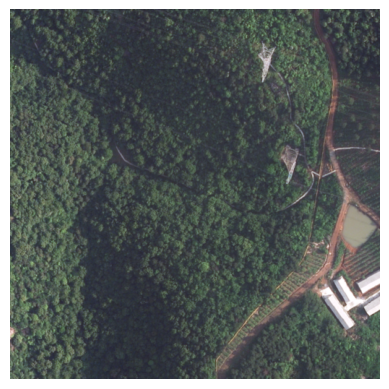

In [17]:
plt.imshow(img.permute(1, 2, 0))
plt.axis("off")

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

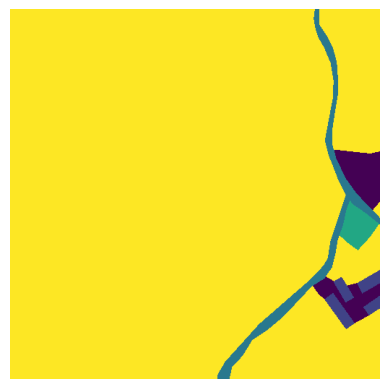

In [18]:
plt.imshow(mask)
plt.axis("off")

In [19]:
"""
0 → No-data
1 → Background
2 → Building
3 → Road
4 → Water
5 → Barren
6 → Forest
7 → Agriculture
"""

'\n0 → No-data\n1 → Background\n2 → Building\n3 → Road\n4 → Water\n5 → Barren\n6 → Forest\n7 → Agriculture\n'

In [20]:
def show_batch(train_loader: DataLoader) -> None:
    batch = next(iter(train_loader))
    images, labels = batch

    for img, mask in zip(images[:8], labels[:8]):
        plt.figure(figsize=(11, 5))

        plt.subplot(1, 2, 1)
        plt.imshow(np.transpose(img.cpu().numpy(), (1, 2, 0)))
        plt.title("Image")
        plt.axis("off")

        plt.subplot(1, 2, 2)
        plt.imshow(mask.cpu().numpy())
        plt.title("Mask")
        plt.axis("off")

        plt.tight_layout()
        plt.show()

In [21]:
def load_data():
    train_dataset = LoveDADataset("/kaggle/input/datasets/mohammedjaveed/loveda-dataset", transforms=TRANSFORMS_DICT)
    val_dataset = LoveDADataset("/kaggle/input/datasets/mohammedjaveed/loveda-dataset", split="Val", transforms=TRANSFORMS_DICT)
    
    train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    num_workers=4,
    pin_memory=True
    )

    val_loader = DataLoader(
    val_dataset,
    batch_size=4,
    shuffle=False,
    num_workers=4,
    pin_memory=True
    )

    return train_loader, val_loader

In [22]:
train_loader, val_loader = load_data()

Train: 2522 samples
Val: 1669 samples


In [23]:
first_batch = next(iter(train_loader))

In [24]:
images, masks = first_batch

In [25]:
print("Images:", images.shape)
print("Masks:", masks.shape)

print("Image dtype:", images.dtype)
print("Mask dtype:", masks.dtype)

print("Mask classes:", torch.unique(masks))

Images: torch.Size([4, 3, 512, 512])
Masks: torch.Size([4, 512, 512])
Image dtype: torch.float32
Mask dtype: torch.int64
Mask classes: tensor([0, 1, 2, 3, 4, 5, 6, 7])


In [26]:
# show_batch(train_loader)

In [27]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models


class DoubleConv(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super(DoubleConv, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.conv(x)
    


class DecoderBlock(nn.Module):
    def __init__(self, in_channels, skip_connections, out_channels):
        super(DecoderBlock, self).__init__()
        self.up = nn.ConvTranspose2d(in_channels, out_channels, kernel_size=2, stride=2)
        self.conv = DoubleConv(out_channels+skip_connections, out_channels)

    def forward(self, x, skip=None):
        x = self.up(x)

        if skip is not None:
            # Padding in case the input dimensions are not perfectly divisible by 2
            diffY = skip.size()[2] - x.size()[2]
            diffX = skip.size()[3] - x.size()[3]
            
            x = F.pad(x, [diffX // 2, diffX - diffX // 2,
                          diffY // 2, diffY - diffY // 2])
            
            # Concatenate along the channel dimension
            x = torch.cat([skip, x], dim=1)

        return self.conv(x)
    


class ResNetUNet(nn.Module):
    def __init__(self, num_classes):
        super(ResNetUNet, self).__init__()
        model = models.resnet34(weights=models.ResNet34_Weights.DEFAULT)

        self.encoder0 = nn.Sequential(
            model.conv1,
            model.bn1,
            model.relu
        )
        self.pool = model.maxpool
        self.encoder1 = model.layer1
        self.encoder2 = model.layer2
        self.encoder3 = model.layer3
        self.encoder4 = model.layer4

        # Decoder
        self.up4 = DecoderBlock(512, 256, 256)
        self.up3 = DecoderBlock(256, 128, 128)
        self.up2 = DecoderBlock(128,  64,  64)
        self.up1 = DecoderBlock( 64,  64,  64)
        self.up0 = DecoderBlock(64, 0, 64)

        self.final_conv = nn.Conv2d(64, num_classes, kernel_size=1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        e0 = self.encoder0(x)
        e1 = self.encoder1(self.pool(e0))
        e2 = self.encoder2(e1)
        e3 = self.encoder3(e2)
        e4 = self.encoder4(e3) # Bottleneck layer

        d = self.up4(e4, skip=e3)
        d = self.up3(d, skip=e2)
        d = self.up2(d, skip=e1)
        d = self.up1(d, skip=e0)
        d = self.up0(d)

        return self.final_conv(d)

In [28]:
# model = ResNetUNet(num_classes=8)

# x = torch.randn(2, 3, 512, 512)

# with torch.no_grad():
#     y = model(x)

# print(x.shape)
# print(y.shape)

In [29]:
# images, masks = next(iter(train_loader))

# images = images.to(device)

# model = ResNetUNet(num_classes=8).to(device)

# with torch.no_grad():
#     outputs = model(images)

# print("Input :", images.shape)
# print("Output:", outputs.shape)
# print("Mask  :", masks.shape)

In [30]:
# import matplotlib.pyplot as plt
# import torch

# images, masks = next(iter(train_loader))

# images = images.to(device)

# model = ResNetUNet(num_classes=8).to(device)

# with torch.no_grad():
#     outputs = model(images)

# print("Input :", images.shape)
# print("Output:", outputs.shape)
# print("Mask  :", masks.shape)

# # Convert logits → predicted class per pixel
# pred = torch.argmax(outputs, dim=1)

# print("Prediction:", pred.shape)

# # Display first prediction
# plt.figure(figsize=(8, 8))
# plt.imshow(pred[0].cpu().numpy(), cmap="tab10")
# plt.colorbar()
# plt.axis("off")
# plt.show()

In [31]:
import torch.nn as nn

model = ResNetUNet(num_classes=8)
model = model.to(device)
criterion = nn.CrossEntropyLoss(ignore_index=0)
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 198MB/s]


In [32]:
from tqdm import tqdm

def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    device
):

    model.train()

    running_loss = 0.0

    for images, masks in tqdm(loader):

        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(
            outputs,
            masks
        )

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    return running_loss / len(loader)


def validate_one_epoch(
    model,
    loader,
    criterion,
    device
):

    model.eval()

    running_loss = 0.0

    with torch.no_grad():

        for images, masks in tqdm(loader):

            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)

            loss = criterion(
                outputs,
                masks
            )

            running_loss += loss.item()

    return running_loss / len(loader)


EPOCHS = 20

best_val_loss = float("inf")

for epoch in range(EPOCHS):

    train_loss = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss = validate_one_epoch(
        model,
        val_loader,
        criterion,
        device
    )

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] "
        f"Train Loss: {train_loss:.4f} "
        f"Val Loss: {val_loss:.4f}"
    )

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        torch.save(
            model.state_dict(),
            "best_model.pth"
        )

        print("Saved best model!")

100%|██████████| 418/418 [00:54<00:00,  7.65it/s]


Epoch [1/20] Train Loss: 1.2870 Val Loss: 1.1275
Saved best model!


100%|██████████| 418/418 [00:54<00:00,  7.63it/s]


Epoch [2/20] Train Loss: 0.9757 Val Loss: 0.9670
Saved best model!


100%|██████████| 418/418 [00:54<00:00,  7.66it/s]


...

Epoch [18/20] Train Loss: 0.3359 Val Loss: 1.0170


100%|██████████| 418/418 [00:54<00:00,  7.69it/s]


Epoch [19/20] Train Loss: 0.3349 Val Loss: 1.1012


100%|██████████| 418/418 [00:54<00:00,  7.69it/s]

Epoch [20/20] Train Loss: 0.2950 Val Loss: 1.2615
